# Fase 5.3 — Modelo baseline y validación cruzada por evento

Clasificador de severidad de 3 niveles (normal / alerta / estrés), confirmado
en `Respuesta_Marlon_Fase5.docx` (sección 1.2 y 1.3):

- **Modelo:** regresión logística multiclase (baseline simple e interpretable).
- **Features de entrada (X):** `volumen_relativo`, `spread_btc_usdc_usdt`,
  `volatilidad_ventana` — señales *indirectas*. No se incluye `desviacion_paridad`
  porque es la variable con la que se construyó la etiqueta `severidad`; usarla
  como feature le daría al modelo la respuesta ya hecha.
- **Validación cruzada por evento:** entrenar con 2 de los 3 eventos ancla y
  validar contra el restante, rotando las 3 combinaciones:

| Entrenamiento | Validación |
|---|---|
| Terra + SVB | FTX |
| Terra + FTX | SVB |
| FTX + SVB | Terra |

- **Métricas:** F1 por clase y matriz de confusión en cada combinación — no solo
  accuracy global, porque la clase `normal` domina el dataset (~90%).

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay, f1_score

pd.set_option("display.max_columns", None)
plt.rcParams["figure.figsize"] = (6, 5)

RUTA_FEATURES = Path("../data/features.parquet")
FEATURES_X = ["volumen_relativo", "spread_btc_usdc_usdt", "volatilidad_ventana"]
CLASES = ["normal", "alerta", "estres"]


## 1. Carga del dataset de features

In [2]:
df = pd.read_parquet(RUTA_FEATURES)
print(f"Filas totales: {len(df):,}")
df.head()


Filas totales: 17,172


,open_time_ts,fuente_paridad,close,volume,desviacion_paridad,severidad,volumen_relativo,fuente_btc_usdc,spread_btc_usdc_usdt,volatilidad_ventana
0,2022-01-01 00:00:00,USDCUSDT,0.9999,2373259.0,0.0001,normal,1.000000,BTCUSDC,-0.000065,NaN
1,2022-01-01 01:00:00,USDCUSDT,0.9999,4955001.0,0.0001,normal,1.352299,BTCUSDC,-0.000035,NaN
2,2022-01-01 02:00:00,USDCUSDT,0.9999,1720917.0,0.0001,normal,0.570522,BTCUSDC,0.000099,0.001341
3,2022-01-01 03:00:00,USDCUSDT,0.9999,3142564.0,0.0001,normal,1.031047,BTCUSDC,-0.000035,0.001338
4,2022-01-01 04:00:00,USDCUSDT,0.9999,957481.0,0.0001,normal,0.364083,BTCUSDC,0.000140,0.001981


## 2. Limpieza de nulos

Se descartan las filas con `NaN` en `spread_btc_usdc_usdt` o `volatilidad_ventana`
(arranque de las ventanas de `pct_change()` y del `merge`, no observaciones de
mercado reales — no se pierde información válida).

In [3]:
antes = len(df)
df = df.dropna(subset=FEATURES_X).reset_index(drop=True)
despues = len(df)

print(f"Filas antes de limpiar: {antes:,}")
print(f"Filas después de limpiar: {despues:,}")
print(f"Filas descartadas: {antes - despues:,}")


Filas antes de limpiar: 17,172
Filas después de limpiar: 17,154
Filas descartadas: 18


## 3. Etiquetado por evento ancla

Cada fila se marca con el evento al que pertenece (según su rango de fechas).
Las filas fuera de las 3 ventanas de evento no se usan en esta validación
cruzada por evento — el diseño experimental definido por el equipo es
específicamente entrenar y validar sobre los eventos ancla, rotando.

In [4]:
EVENTOS = {
    "Terra": ("2022-05-07", "2022-05-17"),
    "FTX": ("2022-11-05", "2022-11-15"),
    "SVB": ("2023-03-08", "2023-03-18"),
}

def asignar_evento(ts):
    for nombre, (inicio, fin) in EVENTOS.items():
        if pd.Timestamp(inicio) <= ts <= pd.Timestamp(fin):
            return nombre
    return None

df["evento"] = df["open_time_ts"].apply(asignar_evento)

df_eventos = df[df["evento"].notna()].reset_index(drop=True)
print("Filas por evento y severidad:")
print(df_eventos.groupby(["evento", "severidad"]).size().unstack(fill_value=0))


Filas por evento y severidad:
severidad  alerta  estres  normal
evento                           
FTX           121      13     107
SVB            51      91      21
Terra         110      22     109


## 4. Validación cruzada por evento (3 combinaciones)

Para cada combinación se entrena una regresión logística multiclase (con
escalado estándar de las features) sobre 2 eventos, y se evalúa sobre el
evento restante. Se reporta F1 por clase y matriz de confusión, no solo
accuracy.

In [5]:
COMBINACIONES = [
    (["Terra", "SVB"], "FTX"),
    (["Terra", "FTX"], "SVB"),
    (["FTX", "SVB"], "Terra"),
]

resultados = []

for eventos_train, evento_test in COMBINACIONES:
    train = df_eventos[df_eventos["evento"].isin(eventos_train)]
    test = df_eventos[df_eventos["evento"] == evento_test]

    X_train, y_train = train[FEATURES_X], train["severidad"]
    X_test, y_test = test[FEATURES_X], test["severidad"]

    escalador = StandardScaler()
    X_train_esc = escalador.fit_transform(X_train)
    X_test_esc = escalador.transform(X_test)

    modelo = LogisticRegression(max_iter=1000, class_weight="balanced")
    modelo.fit(X_train_esc, y_train)

    y_pred = modelo.predict(X_test_esc)

    print("=" * 70)
    print(f"Entrenamiento: {' + '.join(eventos_train)}  ->  Validación: {evento_test}")
    print(f"Filas train: {len(train):,} | Filas test: {len(test):,}")
    print(f"Distribución real en test: {dict(y_test.value_counts())}")
    print()
    print(classification_report(y_test, y_pred, labels=CLASES, zero_division=0))

    f1_por_clase = f1_score(y_test, y_pred, labels=CLASES, average=None, zero_division=0)
    resultados.append({
        "entrenamiento": " + ".join(eventos_train),
        "validacion": evento_test,
        "f1_normal": f1_por_clase[0],
        "f1_alerta": f1_por_clase[1],
        "f1_estres": f1_por_clase[2],
        "y_test": y_test,
        "y_pred": y_pred,
    })


Entrenamiento: Terra + SVB  ->  Validación: FTX
Filas train: 404 | Filas test: 241
Distribución real en test: {'alerta': np.int64(121), 'normal': np.int64(107), 'estres': np.int64(13)}

              precision    recall  f1-score   support

      normal       0.58      0.79      0.67       107
      alerta       0.73      0.30      0.42       121
      estres       0.04      0.15      0.07        13

    accuracy                           0.51       241
   macro avg       0.45      0.42      0.39       241
weighted avg       0.63      0.51      0.51       241

Entrenamiento: Terra + FTX  ->  Validación: SVB
Filas train: 482 | Filas test: 163
Distribución real en test: {'estres': np.int64(91), 'alerta': np.int64(51), 'normal': np.int64(21)}

              precision    recall  f1-score   support

      normal       0.13      1.00      0.23        21
      alerta       0.00      0.00      0.00        51
      estres       0.00      0.00      0.00        91

    accuracy                   

## 5. Matrices de confusión (las 3 combinaciones)

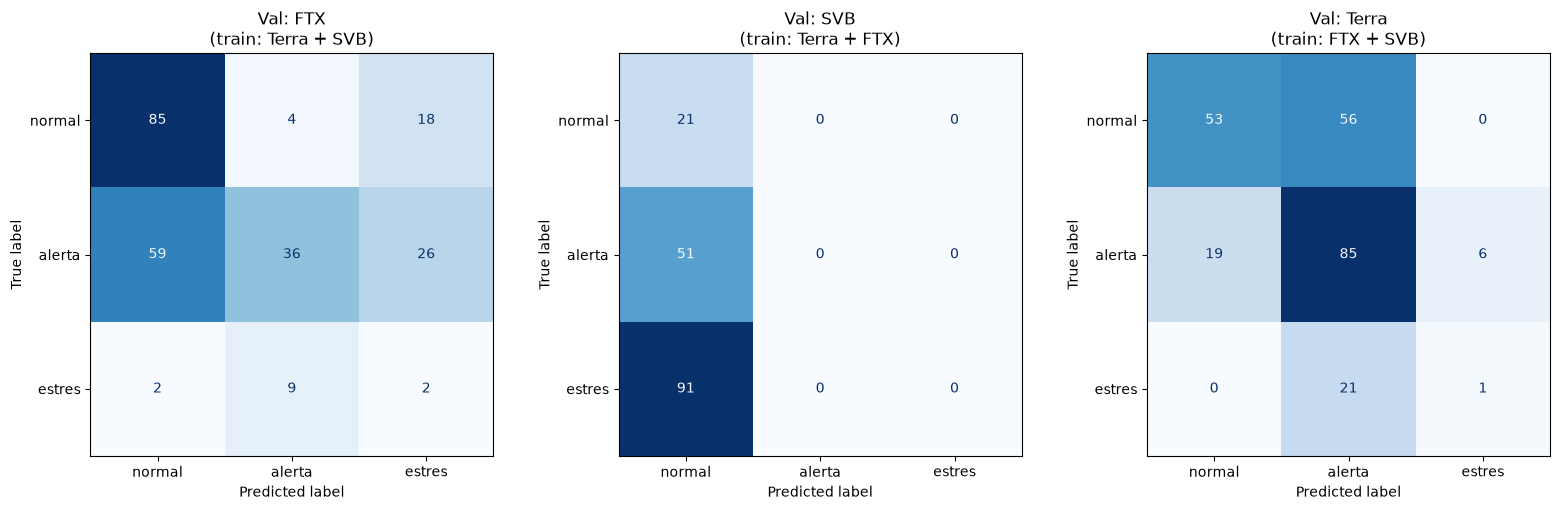

In [6]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

for ax, resultado in zip(axes, resultados):
    matriz = confusion_matrix(resultado["y_test"], resultado["y_pred"], labels=CLASES)
    disp = ConfusionMatrixDisplay(confusion_matrix=matriz, display_labels=CLASES)
    disp.plot(ax=ax, colorbar=False, cmap="Blues")
    ax.set_title(f"Val: {resultado['validacion']}\n(train: {resultado['entrenamiento']})")

plt.tight_layout()
plt.savefig("../informe/fig_matrices_confusion.png", dpi=150)
plt.show()


## 6. Tabla resumen de F1 por clase (para el informe)

In [7]:
resumen_f1 = pd.DataFrame([
    {
        "Entrenamiento": r["entrenamiento"],
        "Validación": r["validacion"],
        "F1 normal": round(r["f1_normal"], 3),
        "F1 alerta": round(r["f1_alerta"], 3),
        "F1 estrés": round(r["f1_estres"], 3),
    }
    for r in resultados
])

resumen_f1


,Entrenamiento,Validación,F1 normal,F1 alerta,F1 estrés
0,Terra + SVB,FTX,0.672,0.424,0.068
1,Terra + FTX,SVB,0.228,0.000,0.000
2,FTX + SVB,Terra,0.586,0.625,0.069


## 7. Resumen para el informe

- Modelo: regresión logística multiclase, features escaladas (`StandardScaler`),
  `class_weight="balanced"` para compensar el desbalance entre clases.
- Features de entrada: `volumen_relativo`, `spread_btc_usdc_usdt`,
  `volatilidad_ventana` (sin `desviacion_paridad`, para no filtrar la etiqueta
  al modelo).
- Las 3 combinaciones de validación cruzada por evento están en `resumen_f1`,
  con matrices de confusión en `informe/fig_matrices_confusion.png`.
- **Nota metodológica pendiente de discutir con el equipo**: la clase `estrés`
  puede tener muy pocas filas en algunos eventos (ver conteo de la sección 3),
  lo que puede producir F1 inestable o 0.0 en esa clase para ciertas
  combinaciones — esto en sí mismo es un hallazgo relevante para la discusión
  del baseline, no un error del notebook.